### This notebook compute "P7. Susceptibility to fluvial flooding" indicator for the 27 basins of IKI Project

Spanish: Susceptibilidad a inundación fluvial

**Created:** 10/23/2025 by Serena Gilson (sgilson@rti.org) 

**Project #:** 0219481

**Last modified:** 1/2/2025 by Sophia (sbakar@rti.org)

**Status:** Complete and value loaded in SQLite. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Hazards  

**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib, rasterstats, rasterio  
 
**Inputs:**   GEOCATMIN - Mapa de susceptibilidad por inundacion fluvial regional, scored by 0 (N/A), 1 (muy bajo baja), 2 (medio), 3 (alta) and Subbasins shapefile, Peru AHD with districts

**Institutions** GEOCATMIN

**Open acess or request data?** Open access from https://geocatmin.ingemmet.gob.pe/geocatmin/
 
**Assumptions:** Weighting score according to formula in each COMID and then rounding to nearest integer.

Weighting formula: 
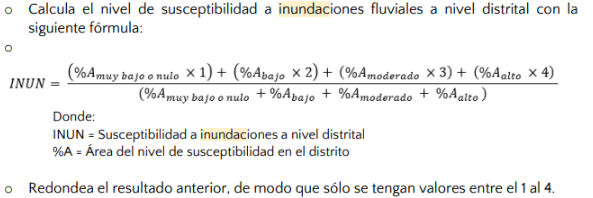

**N/A Handling:** There shouldn't be N/A values because all NA values are assigned a 1 according to the index rules.
 
**Future work:** 
 
**Notes:** p6 raster values are between 0 and 5 whereas p7 values are between 0 and 4. Take note of slight differences in formula.  

General methodology:  
1. Determine the total susceptability pixels in each COMID.  
2. Calculate the percentage of pixels in each category within each COMID.  
3. Calculate the weighted score for each COMID, then round the values to force them to be 1, 2, 3, or 4, respectively indicating low, medium, high, or very high fluvial flood susceptability.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio

In [2]:
# set up user and database path
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 107 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()


In [ ]:
# Define the paths to the shapefile and raster file
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
#mapa_sus_ind = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/3_HIDROLOGIA_HYDROGRAPHY/Mapas_INGEMMET/DGA_SusceptibilidadInundacion/INUNDACION/IMG_SUSCEP_INUN_FLUVIAL1.tif"
# Indicadores/Datos_GEOCATMIN
mapa_sus_ind = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Mapas_INGEMMET\DGA_SusceptibilidadInundacion\INUNDACION\IMG_SUSCEP_INUN_FLUVIAL1.tif"
# Load the shapefile
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

In [5]:
# Perform zonal statistics with categorical counts
stats = zonal_stats(
    subbasins_gdf,  # GeoDataFrame with geometries
    mapa_sus_ind,   # Path to the raster file
    categorical=True,  # Get pixel counts for each category
    geojson_out=True  # Return GeoJSON-like output
)

# Calculate weighted susceptibility score for each COMID
weighted_scores = []

for feature in stats:
    comid = feature['properties']['COMID']
    pixel_counts = {k: v for k, v in feature['properties'].items() if isinstance(k, (int, float))}
    
    # Calculate total pixels
    total_pixels = sum(pixel_counts.values())
    
    if total_pixels == 0:
        weighted_scores.append({'COMID': comid, 'weighted_susceptibility': 1}) #according to annex null values should get a 1
        continue
    
    # Calculate area percentages for each category
    # Category 0 or 1 = N/A or very low
    pct_0_or_1 = (pixel_counts.get(0, 0) + pixel_counts.get(1, 0)) / total_pixels
    # Category 2 = medium
    pct_2 = pixel_counts.get(2, 0) / total_pixels
    # Category 3 = high
    pct_3 = pixel_counts.get(3, 0) / total_pixels
    # Category 4 = very high
    pct_4 = pixel_counts.get(4, 0) / total_pixels
    
    # Calculate weighted score
    numerator = (pct_0_or_1 * 1) + (pct_2 * 2) + (pct_3 * 3) + (pct_4 * 4)
    denominator = pct_0_or_1 + pct_2 + pct_3 + pct_4
    
    if denominator > 0:
        weighted_score = numerator / denominator
        # Round to nearest integer and clip to 1-4 range
        weighted_score = np.clip(round(weighted_score), 1, 4)
    else:
        weighted_score = 1 #according to annex null values should get a 1
    
    weighted_scores.append({'COMID': comid, 'weighted_susceptibility': weighted_score})

# Convert to DataFrame
weighted_scores_df = pd.DataFrame(weighted_scores)

# Merge with subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(
    weighted_scores_df,
    on="COMID",
    how="left"
)

# Fill in NaN values with 0 
#subbasins_gdf['weighted_susceptibility'] = subbasins_gdf['weighted_susceptibility'].fillna(0)

# Display the results
print(subbasins_gdf[["COMID", "weighted_susceptibility"]].head())
print(f"\nSummary statistics:")
print(subbasins_gdf['weighted_susceptibility'].describe())

       COMID  weighted_susceptibility
0  311153600                        2
1  310832400                        2
2  310825700                        2
3  310282400                        3
4  308754600                        1

Summary statistics:
count    3655.000000
mean        1.496854
std         0.717617
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: weighted_susceptibility, dtype: float64


<Axes: >

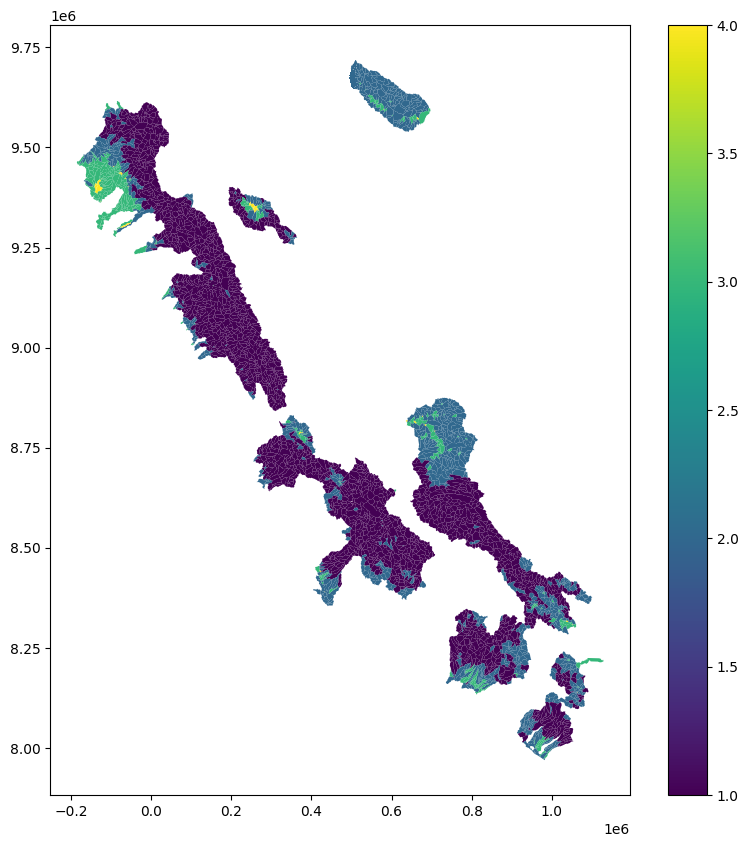

In [6]:
# Plot the weighted susceptibility values
subbasins_gdf.plot(column="weighted_susceptibility", cmap="viridis", legend=True, figsize=(10, 10))

In [7]:
# Insert results into the database

insert_data = subbasins_gdf
value_column = 'weighted_susceptibility'

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        rows_to_insert.append((
            scn_id,
            IndID,
            int(row['COMID']),
            int(row[value_column]) if not pd.isna(row[value_column]) else None
        ))



In [8]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['weighted_susceptibility']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 107  Min: 1, Max: 4

=== Values to be inserted (by scenario) ===
   index  weighted_susceptibility
0    min                        1
1    max                        4
2  count                     3655
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [9]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()